# Proyek Analisis Data: [E-Commerce Public Dataset
- **Nama:** Sifa Mutiasya Hendayana Puteri
- **Email:** sifamutiasya@gmail.com
- **ID Dicoding:** CDCC222D6X0835

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penjualan e-commerce berdasarkan waktu (bulanan) dan kategori produk?
- Bagaimana segmentasi pelanggan berdasarkan RFM (Recency, Frequency, Monetary) dan karakteristik tiap segmen?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import geopandas as gpd
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [ ]:
orders = pd.read_csv("orders_dataset.csv")
order_items = pd.read_csv("order_items_dataset.csv")
customers = pd.read_csv("customers_dataset.csv")
products = pd.read_csv("products_dataset.csv")
payments = pd.read_csv("order_payments_dataset.csv")

**Insight:**
- Data terdiri dari beberapa tabel terpisah (relational dataset).
- Perlu dilakukan merging untuk analisis komprehensif.

### Assessing Data

In [ ]:
orders.info()
orders.isna().sum()
orders.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


np.int64(0)

**Insight:**
- Seluruh kolom bertipe object, termasuk kolom tanggal.
- Tidak terdapat duplikasi data.
- Terdapat missing value pada order_approved_at, order_delivered_carrier_date, order_delivered_customer_date.

In [ ]:
order_items.info()
order_items.isna().sum()
order_items.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


np.int64(0)

**Insight:**
- Tidak terdapat missing value maupun duplikasi.
- Satu order_id dapat memiliki lebih dari satu order_item_id
- Kolom price dan freight_value digunakan untuk menghitung revenue.
- Perlu agregasi sebelum merging agar tidak terjadi double counting saat analisis.

In [ ]:
customers.info()
customers.isna().sum()
customers.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


np.int64(0)

**Insight:**
- Tidak terdapat missing value maupun duplikasi.
- customer_unique_id memungkinkan identifikasi pelanggan unik.
- Satu pelanggan dapat memiliki beberapa transaksi (penting untuk Frequency pada RFM).
- Terdapat informasi lokasi (city dan state) yang bisa digunakan untuk analisis distribusi pelanggan.

In [ ]:
products.info()
products.isna().sum()
products.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


np.int64(0)

**Insight:**
- Terdapat missing value pada product_category_name dan Beberapa kolom dimensi produk.
- Tidak terdapat duplikasi.
- Kolom product_category_name penting untuk analisis kategori produk.
- Missing kategori perlu ditangani agar visualisasi tidak bias.

In [ ]:
payments.info()
payments.isna().sum()
payments.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


np.int64(0)

**Insight:**
- Tidak terdapat missing value maupun duplikasi.
- Satu order_id bisa memiliki lebih dari satu pembayaran (installment).
- Kolom payment_value menjadi dasar perhitungan Monetary pada RFM.
- Perlu agregasi berdasarkan order_id sebelum digabung dengan tabel lain.

### Cleaning Data

In [ ]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders = orders[orders["order_status"] == "delivered"]

orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


**Insight:**
- Menghindari bias dari order yang dibatalkan
- Memastikan analisis tren waktu dan Recency akurat

In [ ]:
order_items["total_price"] = order_items["price"] + order_items["freight_value"]

order_items_agg = order_items.groupby("order_id").agg({
    "total_price": "sum"
}).reset_index()

**Insight:**
- Menghindari perhitungan revenue berulang saat merging

In [ ]:
customers = customers.drop_duplicates(subset="customer_id")

**Insight:**
- Menjaga integritas relasi saat merging
- Memastikan RFM dihitung berdasarkan pelanggan unik

In [ ]:
products["product_category_name"] = \
products["product_category_name"].fillna("Unknown")

**Insight:**
- Menghindari kehilangan data saat analisis kategori
- Mencegah bar chart menampilkan NaN

In [ ]:
payments_agg = payments.groupby("order_id").agg({
    "payment_value": "sum"
}).reset_index()

**Insight:**
- Menghitung Monetary secara akurat
- Menghindari duplikasi nilai pembayaran

In [ ]:
df = orders.merge(customers, on="customer_id") \
           .merge(order_items_agg, on="order_id") \
           .merge(payments_agg, on="order_id") \
           .merge(order_items[["order_id","product_id"]], on="order_id") \
           .merge(products[["product_id","product_category_name"]], on="product_id")
df.to_csv("data_utama.csv", index=False)

**Insight:**
- Data dari beberapa tabel berhasil digabung menjadi satu dataset utama untuk analisis.
- Dataset sudah mencakup informasi waktu transaksi, pelanggan, nilai pembayaran, dan kategori produk.

## Exploratory Data Analysis (EDA)

### Explore Tren Penjualan Bulanan

In [ ]:
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")
monthly_sales = df.groupby("order_month")["payment_value"].sum().reset_index()

monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)
monthly_sales.head()

,order_month,payment_value
0,2016-10,61746.94
1,2016-12,19.62
2,2017-01,176491.49
3,2017-02,325782.66
4,2017-03,505735.83


**Insight:**
- Revenue sangat rendah di akhir 2016
- Terjadi lonjakan signifikan sejak Januari 2017.
- Kenaikan dari Januari ke Maret 2017 menunjukkan pertumbuhan yang agresif.
- Pola ini mengindikasikan ekspansi bisnis dan peningkatan aktivitas transaksi.

### Explore Jumlah Transaksi Bulanan

In [ ]:
monthly_orders = df.groupby("order_month")["order_id"].nunique().reset_index()

monthly_orders.head()

,order_month,order_id
0,2016-10,265
1,2016-12,1
2,2017-01,750
3,2017-02,1653
4,2017-03,2546


**Insight:**
- Jumlah order meningkat drastis di awal 2017.
- Lonjakan transaksi konsisten dengan kenaikan revenue.
- Pertumbuhan pendapatan terutama didorong oleh peningkatan volume order.
- Tidak ada indikasi penurunan ekstrem pada periode awal pertumbuhan.

### Explore Kategori Produk dengan Revenue Tertinggi

In [ ]:
top_category = df.groupby("product_category_name")["payment_value"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_category

,payment_value
product_category_name,
cama_mesa_banho,1692714.28
beleza_saude,1620684.04
informatica_acessorios,1549372.59
moveis_decoracao,1394466.93
relogios_presentes,1387362.45
esporte_lazer,1349446.93
utilidades_domesticas,1069787.97
automotivo,833745.67
ferramentas_jardim,810614.93


**Insight:**
- Kategori dengan kontribusi terbesar yaitu cama_mesa_banho.
- Produk rumah tangga dan lifestyle mendominasi penjualan.
- Distribusi menunjukkan potensi efek Pareto (sebagian kecil kategori menyumbang proporsi besar revenue).
- Kategori unggulan dapat menjadi fokus strategi pemasaran dan pengelolaan stok.

### Explore Distribusi Revenue Pelanggan

In [ ]:
customer_revenue = df.groupby("customer_unique_id")["payment_value"].sum()

customer_revenue.describe()

,payment_value
count,93357.000000
mean,211.833718
std,642.166523
min,9.590000
25%,63.760000
50%,112.950000
75%,201.740000
max,109312.640000


**Insight:**
- Rata-rata (211) lebih tinggi dari median (112).
- Terdapat transaksi bernilai sangat tinggi (maks >100.000).
- Mayoritas pelanggan berada pada transaksi bernilai rendah-menengah.
- Terdapat segmen pelanggan dengan kontribusi revenue sangat besar.

### Explore Frekuensi Pembelian Pelanggan

In [ ]:
customer_frequency = df.groupby("customer_unique_id")["order_id"].nunique()

customer_frequency.describe()

,order_id
count,93357.000000
mean,1.033420
std,0.209099
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000


**Insight:**
- Median = 1 (mayoritas pelanggan hanya membeli sekali).
- Nilai maksimum 15 terdapat pelanggan dengan loyalitas tinggi.
- Rata-rata mendekati 1 repeat customer relatif sedikit.
- Menunjukkan peluang besar untuk strategi retensi dan peningkatan loyalitas.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penjualan e-commerce berdasarkan waktu (bulanan) dan kategori produk?

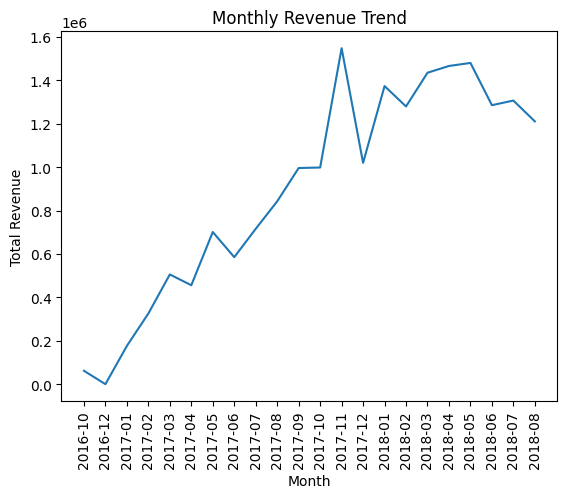

In [ ]:
monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)

plt.figure()
plt.plot(monthly_sales["order_month"], monthly_sales["payment_value"])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

**Insight:**
- Revenue meningkat signifikan sepanjang 2017.
- Tahun 2016 menunjukkan volume transaksi yang masih sangat rendah.
- Terdapat pola pertumbuhan konsisten yang menunjukkan fase ekspansi bisnis.
- Peningkatan revenue sejalan dengan pertumbuhan jumlah order.

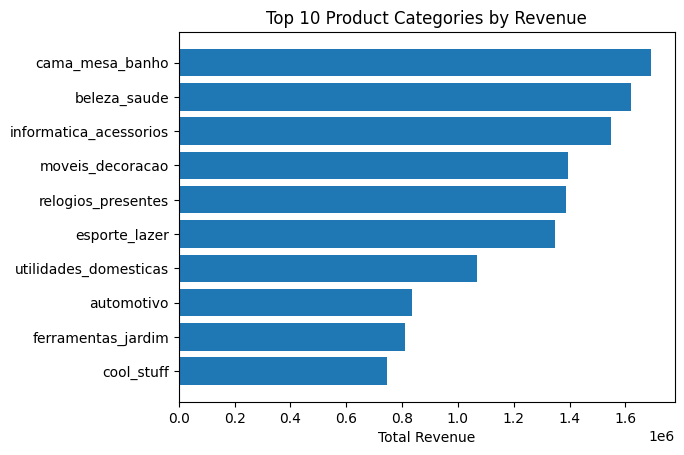

In [ ]:
top_category = df.groupby("product_category_name")["payment_value"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure()
plt.barh(top_category.index, top_category.values)
plt.gca().invert_yaxis()
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.show()

### Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan RFM (Recency, Frequency, Monetary) dan karakteristik tiap segmen?

In [ ]:
snapshot_date = df["order_purchase_timestamp"].max() + dt.timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


**Insight:**
- Mayoritas pelanggan berada pada skor rendah–menengah.
- Terdapat segmen pelanggan dengan skor tinggi (high value customers).
- Distribusi menunjukkan ketimpangan kontribusi revenue.
- Segmen dengan Frequency dan Monetary tinggi berpotensi menjadi loyal customer.
- Pelanggan dengan Recency tinggi tetapi Frequency rendah berisiko churn.

## Analisis Lanjutan (Opsional)

In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_score"] = rfm["R_score"].astype(str) + \
                   rfm["F_score"].astype(str) + \
                   rfm["M_score"].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,3,213


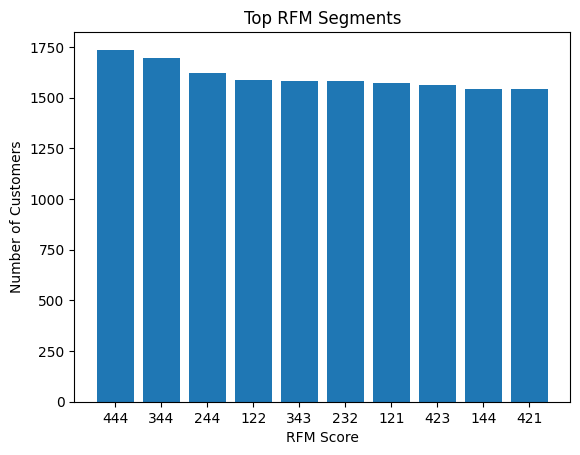

In [ ]:
rfm_segment = rfm["RFM_score"].value_counts().head(10)

plt.figure()
plt.bar(rfm_segment.index, rfm_segment.values)
plt.title("Top RFM Segments")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.show()

## Conclusion

- Penjualan e-commerce menunjukkan pola pertumbuhan signifikan sejak awal 2017. Peningkatan revenue didorong oleh kenaikan jumlah transaksi yang konsisten setiap bulan. Selain itu, kontribusi pendapatan terkonsentrasi pada beberapa kategori utama, terutama produk rumah tangga dan lifestyle. Hal ini menunjukkan bahwa performa bisnis sangat dipengaruhi oleh kategori tertentu serta momentum pertumbuhan pasar pada periode tersebut.
- Hasil segmentasi RFM menunjukkan bahwa mayoritas pelanggan memiliki frekuensi pembelian rendah dan kontribusi monetary terbatas. Namun, terdapat segmen pelanggan bernilai tinggi yang menyumbang proporsi revenue signifikan. Distribusi ini menegaskan pentingnya strategi retensi dan loyalitas pelanggan, khususnya untuk mempertahankan pelanggan dengan skor RFM tinggi dan mengoptimalkan potensi pelanggan dengan aktivitas pembelian yang mulai menurun.